# 🎬 Analyse de sentiment — Fine-tuning CamemBERT
## Notebook 2/2

**Auteur :** Diogo Almeida
**Modèle :** [CamemBERT-base](https://huggingface.co/camembert-base)

**⚠️ GPU recommandé** — Ce notebook fine-tune un modèle Transformer.
- En local : GPU NVIDIA avec CUDA
- Sur Google Colab : Runtime → Change runtime type → GPU (gratuit)

In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    CamembertTokenizer, CamembertForSequenceClassification,
    TrainingArguments, Trainer,
)
from datasets import Dataset
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import joblib
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_RAW = Path('..') / 'data' / 'raw'
MODELS = Path('..') / 'models'
ASSETS = Path('..') / 'assets'

# Vérifier GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
if device == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')

Device : cpu


## 1. Chargement et préparation

In [2]:
df = pd.read_csv(DATA_RAW / 'allocine_dataset.csv')
print(f'Corpus : {len(df):,} critiques')

# Splits
train = df[df['split'] == 'train'].copy()
test = df[df['split'] == 'test'].copy()
val = df[df['split'] == 'validation'].copy() if 'validation' in df['split'].values else None

# Sous-échantillonner si pas de GPU (sinon trop lent)
if device == 'cpu':
    print('\n⚠️  Pas de GPU — sous-échantillonnage pour la démo')
    train = train.sample(5000, random_state=42)
    test = test.sample(1000, random_state=42)
    if val is not None:
        val = val.sample(1000, random_state=42)

print(f'Train : {len(train):,}')
print(f'Test : {len(test):,}')
if val is not None:
    print(f'Val : {len(val):,}')

Corpus : 200,000 critiques

⚠️  Pas de GPU — sous-échantillonnage pour la démo
Train : 5,000
Test : 1,000


In [3]:
# Tokenizer CamemBERT
tokenizer = CamembertTokenizer.from_pretrained('camembert-base')

def tokenize_data(texts, labels, max_length=256):
    """Tokenize et retourne un HF Dataset."""
    encodings = tokenizer(
        texts.tolist(),
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors=None,
    )
    dataset = Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': labels.tolist(),
    })
    return dataset

print('Tokenisation...')
train_dataset = tokenize_data(train['review'].astype(str), train['label'].astype(int))
test_dataset = tokenize_data(test['review'].astype(str), test['label'].astype(int))
val_dataset = tokenize_data(val['review'].astype(str), val['label'].astype(int)) if val is not None else test_dataset

print(f'Train tokenisé : {len(train_dataset)}')
print(f'Test tokenisé : {len(test_dataset)}')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

Tokenisation...
Train tokenisé : 5000
Test tokenisé : 1000


## 2. Fine-tuning CamemBERT

In [4]:
# Charger le modèle pré-entraîné
model = CamembertForSequenceClassification.from_pretrained(
    'camembert-base',
    num_labels=2,
)

# Arguments d'entraînement
training_args = TrainingArguments(
    output_dir=str(MODELS / 'camembert_checkpoints'),
    num_train_epochs=3,
    per_device_train_batch_size=16 if device == 'cuda' else 8,
    per_device_eval_batch_size=32 if device == 'cuda' else 16,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none',
    fp16=device == 'cuda',
)

# Métriques
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds)
    return {'f1': f1}

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print('Lancement du fine-tuning...')
print(f'  Epochs : {training_args.num_train_epochs}')
print(f'  Batch size : {training_args.per_device_train_batch_size}')
print(f'  Learning rate : {training_args.learning_rate}')

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Lancement du fine-tuning...
  Epochs : 3
  Batch size : 8
  Learning rate : 2e-05


In [5]:
# Entraîner
train_result = trainer.train()
print(f'\nEntraînement terminé')
print(f'  Loss finale : {train_result.training_loss:.4f}')

Epoch,Training Loss,Validation Loss,F1
1,0.205090,0.195755,0.947154
2,0.082910,0.212154,0.952764
3,0.077705,0.223815,0.950153


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Entraînement terminé
  Loss finale : 0.1980


## 3. Évaluation

CamemBERT F1 : 0.9528

              precision    recall  f1-score   support

     Négatif       0.97      0.94      0.95       510
     Positif       0.94      0.97      0.95       490

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



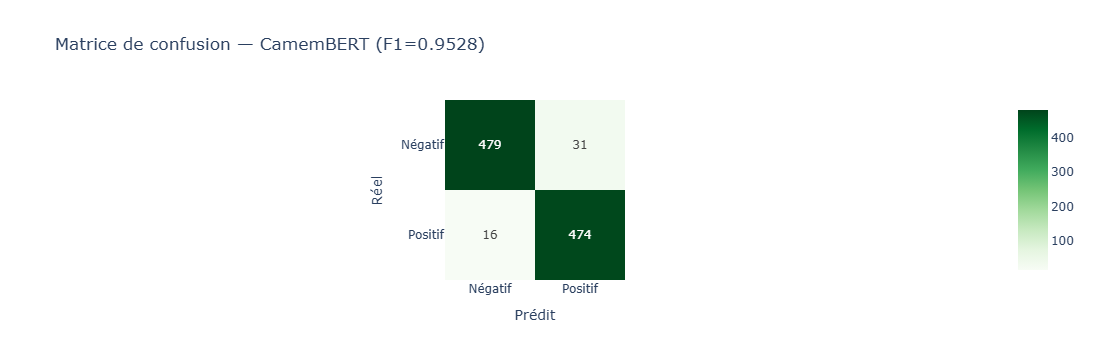

In [6]:
# Prédictions sur le test set
preds_output = trainer.predict(test_dataset)
y_pred_camembert = preds_output.predictions.argmax(-1)
y_test_arr = np.array(test['label'].astype(int).tolist())

f1_camembert = f1_score(y_test_arr, y_pred_camembert)
print(f'CamemBERT F1 : {f1_camembert:.4f}')
print(f'\n{classification_report(y_test_arr, y_pred_camembert, target_names=["Négatif", "Positif"])}')

cm = confusion_matrix(y_test_arr, y_pred_camembert)
fig = px.imshow(cm, text_auto=True, title=f'Matrice de confusion — CamemBERT (F1={f1_camembert:.4f})',
    labels=dict(x='Prédit', y='Réel'),
    x=['Négatif', 'Positif'], y=['Négatif', 'Positif'],
    color_continuous_scale='Greens', template='plotly_white')
fig.show()
fig.write_image(ASSETS / '04_confusion_camembert.png', scale=2)

## 4. Comparaison Baseline vs CamemBERT

,Modèle,F1,Type
0,Baseline (Linear SVM),0.939200,NLP Classique
1,CamemBERT (fine-tuné),0.952764,Deep Learning



Amélioration CamemBERT vs Baseline : +1.4 points de F1


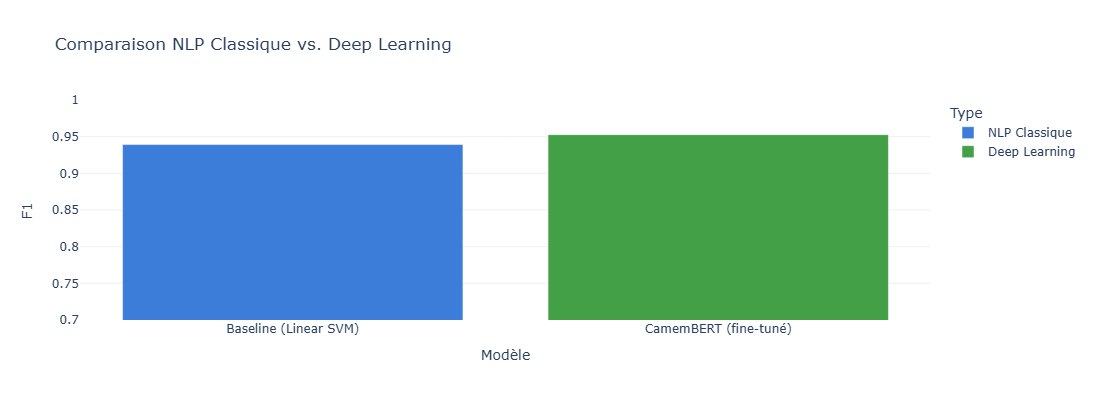

In [7]:
# Charger les résultats du baseline
try:
    baseline = joblib.load(MODELS / 'baseline_results.pkl')
    baseline_f1 = baseline['f1']
    baseline_name = baseline['name']
except:
    baseline_f1 = 0.85  # Estimation si pas encore exécuté
    baseline_name = 'TF-IDF Baseline'

# Comparaison
comparison = pd.DataFrame([
    {'Modèle': f'Baseline ({baseline_name})', 'F1': baseline_f1, 'Type': 'NLP Classique'},
    {'Modèle': 'CamemBERT (fine-tuné)', 'F1': f1_camembert, 'Type': 'Deep Learning'},
])

display(comparison)

improvement = (f1_camembert - baseline_f1) * 100
print(f'\nAmélioration CamemBERT vs Baseline : {improvement:+.1f} points de F1')

fig = px.bar(comparison, x='Modèle', y='F1', color='Type',
    title='Comparaison NLP Classique vs. Deep Learning',
    color_discrete_map={'NLP Classique': '#3B7DD8', 'Deep Learning': '#43A047'},
    template='plotly_white', height=400)
fig.update_layout(yaxis_range=[0.7, 1.0])
fig.show()
fig.write_image(ASSETS / '05_comparaison_baseline_camembert.png', scale=2)

## 5. Analyse d'erreurs

In [8]:
# Exemples où CamemBERT se trompe
test_analysis = test.copy().reset_index(drop=True)
test_analysis['pred'] = y_pred_camembert
test_analysis['correct'] = test_analysis['label'] == test_analysis['pred']

errors = test_analysis[~test_analysis['correct']]
print(f'Erreurs CamemBERT : {len(errors)} / {len(test_analysis)} ({len(errors)/len(test_analysis)*100:.1f}%)')

print(f'\n--- Exemples d\'erreurs ---')
for _, row in errors.sample(min(5, len(errors)), random_state=42).iterrows():
    label_str = 'Positif' if row['label'] == 1 else 'Négatif'
    pred_str = 'Positif' if row['pred'] == 1 else 'Négatif'
    print(f'  Réel: {label_str} | Prédit: {pred_str}')
    print(f'  "{str(row["review"])[:200]}..."\n')

Erreurs CamemBERT : 47 / 1000 (4.7%)

--- Exemples d'erreurs ---
  Réel: Négatif | Prédit: Positif
  "Habitué des projets chocs (longs et courts métrages, téléfilms, documentaires) même s'il s'agit que de son second film, Jean-Stéphane Sauvaire revient sur l'histoire vraie de Billy Moore, ce jeune box..."

  Réel: Négatif | Prédit: Positif
  "Biopic sur le debut de la vie de bruce lee du point de vue de son frere Cadet Robert Lee Ici pas de baston mais de la nostalgie sur sa jeunesse a Hong kong,ses amis,ses sentiments c'est tres soigné et..."

  Réel: Négatif | Prédit: Positif
  "Beaucoup diront que ce "Hangman" est un ersatz de "Seven" et que Al Pacino joue une fois de plus les flics fatiguès et blasès! C'est indiscutablement vrai! La plupart des flics à la retraite vont à la..."

  Réel: Négatif | Prédit: Positif
  "C'est un film. Il y a du rouge. Une jolie actrice qui a l'air tarte pendant tout le film, dont la vie lui échappe totalement, elle a au moins l'honnêteté de ne pas préte

## 6. Sauvegarde

In [9]:
# Sauvegarder le modèle fine-tuné
model_path = MODELS / 'camembert_finetuned'
trainer.save_model(str(model_path))
tokenizer.save_pretrained(str(model_path))

# Sauvegarder les résultats
joblib.dump({
    'f1_camembert': f1_camembert,
    'f1_baseline': baseline_f1,
    'improvement': improvement,
}, MODELS / 'comparison_results.pkl')

print(f'Modèle sauvegardé : {model_path}')
print(f'F1 CamemBERT : {f1_camembert:.4f}')
print(f'F1 Baseline : {baseline_f1:.4f}')
print(f'Amélioration : {improvement:+.1f} points')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle sauvegardé : ..\models\camembert_finetuned
F1 CamemBERT : 0.9528
F1 Baseline : 0.9392
Amélioration : +1.4 points


---

*Notebook réalisé par Diogo Almeida — Septembre 2026*